# Section 5: Multi-Head Attention

In Section 4 we built a single attention head: one set of projections `W_Q, W_K, W_V`, producing **one** attention pattern per token — one weighted average over the sequence.

But a token relates to others in *several* ways at once. In "The animal didn't cross the street because **it** was too tired", the token "it" simultaneously wants to track:

- its **referent** ("animal") — a coreference relationship,
- its **grammatical role** (subject of "was") — a syntactic relationship,
- its **topic** (tiredness / animals) — a semantic relationship.

A single head, having one `W_Q, W_K, W_V`, can only learn *one composite* of these. **Multi-head attention** runs `h` heads in parallel, each with its own projections, and concatenates their outputs. With `d_k = d_v = d_model / h`, the total parameters and compute stay about the same as one big head — but the model gets `h` independent attention patterns per layer.

The procedure, in four steps:

1. **Project** `X` to `Q, K, V` of shape `(T, d_model)`, then **split** each into `h` heads of shape `(T, d_k)` with `d_k = d_model / h`.
2. Run **scaled dot-product attention** independently on each head.
3. **Concatenate** the `h` outputs along the feature axis, recovering `(T, d_model)`.
4. Apply a final **output projection** `W_O` of shape `(d_model, d_model)` to mix information across heads.


## Setup

Multi-head attention is built directly on the scaled dot-product attention from Section 4. To keep this notebook self-contained, we re-define the small pieces we need inline:

- the tokenizer + embedding lookup to get `X` of shape `(T, d_model)`,
- `softmax`, and
- `scaled_dot_product_attention` — the exact primitive from 4.6.

We use `D_MODEL = 8`, `seed = 42`, and the same sentence as before, so every number is reproducible and small enough to print.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tokenizer import CharTokenizer

D_MODEL = 8  # token vector size — kept small so we can print whole vectors

# Fixed seed: identical random numbers every run, essential for debugging.
rng = np.random.default_rng(seed=42)

sentence = "the cat sat on the mat"
tok = CharTokenizer(sentence)
ids = tok.encode(sentence)

# Embedding matrix (vocab_size, d_model), then look up one row per token -> X (T, d_model).
# Same 1/sqrt(d_model) init as the earlier notebooks, so X is identical to Section 4's X.
scale = 1.0 / np.sqrt(D_MODEL)
E = rng.normal(0.0, scale, size=(tok.vocab_size, D_MODEL))
X = E[ids]

print(f"Sentence : {sentence!r}")
print(f"Token IDs: {ids}")
print(f"X shape  : {X.shape}  -> (seq_len={len(ids)}, d_model={D_MODEL})")

Matplotlib is building the font cache; this may take a moment.


Sentence : 'the cat sat on the mat'
Token IDs: [9, 4, 3, 0, 2, 1, 9, 0, 8, 1, 9, 0, 7, 6, 0, 9, 4, 3, 0, 5, 1, 9]
X shape  : (22, 8)  -> (seq_len=22, d_model=8)


In [2]:
def softmax(x: np.ndarray, axis: int = -1) -> np.ndarray:
    # Subtract the row max before exponentiating — pure numerical stability,
    # mathematically identical because the constant cancels.
    x_shifted = x - np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(x_shifted)
    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)


def scaled_dot_product_attention(Q, K, V, mask=None):
    # The exact primitive from Section 4.6. Q:(Tq,d_k) K:(Tk,d_k) V:(Tk,d_v).
    d_k = Q.shape[-1]
    scores = Q @ K.T                 # (Tq, Tk): raw query-key similarity
    scores = scores / np.sqrt(d_k)   # keep magnitudes ~O(1) so softmax doesn't saturate
    if mask is not None:
        scores = np.where(mask, -1e9, scores)  # masked positions get ~0 weight
    A = softmax(scores, axis=-1)     # (Tq, Tk): row-normalised weights
    Y = A @ V                        # (Tq, d_v): weighted sum of values
    return Y, A


# Sanity check: single-head attention on X reproduces the Section 4 primitive.
Y_check, A_check = scaled_dot_product_attention(X, X, X)
print(f"Single-head self-attention output: {Y_check.shape}  (T, d_model)")
print(f"Attention row sums (must be 1.0):  {A_check.sum(axis=-1).round(4)}")

Single-head self-attention output: (22, 8)  (T, d_model)
Attention row sums (must be 1.0):  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 5.1 — Why More Than One Head?

A single head collapses *all* the ways a token relates to others into one attention distribution. If "it" needs to attend to its referent for one purpose and to its verb for another, a single head must compromise on a blend of the two.

Multi-head attention sidesteps the compromise: give the model `h` separate heads, each with its own `W_Q, W_K, W_V`, and each is free to specialise. Head 0 might learn "attend to the previous token", head 1 "attend to the matching subject", and so on. After mechanistic-interpretability work on real transformers, heads with clean roles — *previous-token head*, *induction head*, *name-mover head* — are routinely found.

The design constraint that makes this cheap: instead of `h` heads each of width `d_model`, we use `h` heads each of width `d_k = d_model / h`. The heads **partition** the `d_model` feature space rather than duplicating it, so total compute matches a single full-width head.


In [3]:
N_HEADS = 2                 # number of parallel attention heads
assert D_MODEL % N_HEADS == 0, "d_model must be divisible by n_heads"
D_K = D_MODEL // N_HEADS    # per-head dimensionality

print(f"d_model = {D_MODEL}")
print(f"n_heads = {N_HEADS}")
print(f"d_k = d_model / n_heads = {D_K}  (each head works in a {D_K}-dim subspace)")
print()
print(f"One full-width head would use d_k = {D_MODEL}.")
print(f"Here {N_HEADS} heads x {D_K} dims = {N_HEADS * D_K} = d_model -> same total width, split across heads.")

d_model = 8
n_heads = 2
d_k = d_model / n_heads = 4  (each head works in a 4-dim subspace)

One full-width head would use d_k = 8.
Here 2 heads x 4 dims = 8 = d_model -> same total width, split across heads.


## 5.2 — Splitting `d_model` into Heads

We store `W_Q, W_K, W_V` each as a single `(d_model, d_model)` matrix rather than `h` separate `(d_model, d_k)` matrices. The split into heads happens by **reshape** in the forward pass. This is exactly what PyTorch's `nn.MultiheadAttention` does internally, and it is more efficient than looping over separate matrices.

After projecting `X @ W_Q` to `Q` of shape `(T, d_model)`, we reshape the feature axis `d_model` into `(h, d_k)` and move the head axis to the front:

```
(T, d_model)  ->  (T, h, d_k)  --transpose-->  (h, T, d_k)
```

Now `Q_h[i]` is head `i`'s `(T, d_k)` query block — ready to feed into scaled dot-product attention on its own.


In [4]:
# Projection matrices, each (d_model, d_model). Same 1/sqrt(d_model) init scale.
proj_scale = 1.0 / np.sqrt(D_MODEL)
W_Q = rng.normal(0.0, proj_scale, size=(D_MODEL, D_MODEL))
W_K = rng.normal(0.0, proj_scale, size=(D_MODEL, D_MODEL))
W_V = rng.normal(0.0, proj_scale, size=(D_MODEL, D_MODEL))

# Project the whole input once, full width.
Q = X @ W_Q  # (T, d_model)
K = X @ W_K  # (T, d_model)
V = X @ W_V  # (T, d_model)
print(f"Q, K, V full-width shapes: {Q.shape}  (T, d_model)")
print()

T = X.shape[0]

def split_heads(M):
    # (T, d_model) -> (T, h, d_k) -> (h, T, d_k).
    # The reshape carves the feature axis into h contiguous blocks of width d_k;
    # the transpose puts the head axis first so each head is an independent (T, d_k) slice.
    return M.reshape(T, N_HEADS, D_K).transpose(1, 0, 2)

Q_h = split_heads(Q)  # (h, T, d_k)
K_h = split_heads(K)
V_h = split_heads(V)

print(f"After split_heads: {Q_h.shape}  (n_heads, T, d_k)")
print()
# Show that head 0 and head 1 really are different slices of the same projected Q.
print(f"Head 0, token 0 query (first {D_K} dims of Q[0]): {Q_h[0, 0].round(3)}")
print(f"Head 1, token 0 query (last  {D_K} dims of Q[0]): {Q_h[1, 0].round(3)}")
print(f"Concatenated they equal the full Q[0]:           {np.allclose(np.concatenate([Q_h[0,0], Q_h[1,0]]), Q[0])}")

Q, K, V full-width shapes: (22, 8)  (T, d_model)

After split_heads: (2, 22, 4)  (n_heads, T, d_k)

Head 0, token 0 query (first 4 dims of Q[0]): [-0.177  0.044 -0.099 -0.173]
Head 1, token 0 query (last  4 dims of Q[0]): [ 0.215 -0.16  -0.109 -0.158]
Concatenated they equal the full Q[0]:           True


## 5.3 — Attention Per Head

Each head is now just a standard scaled dot-product attention over its own `(T, d_k)` blocks. We run the Section 4 primitive once per head and collect:

- `head_outputs[i]` — head `i`'s output, shape `(T, d_k)`,
- `head_attentions[i]` — head `i`'s attention matrix, shape `(T, T)`.

The heads are fully independent here — no information crosses between them until the concatenation in 5.4.


In [5]:
head_outputs = []
head_attentions = []
for i in range(N_HEADS):
    # Each head attends within its own d_k-dim subspace. Note d_k=4 here, so the
    # 1/sqrt(d_k) scaling inside the primitive uses sqrt(4)=2, not sqrt(8).
    Y_i, A_i = scaled_dot_product_attention(Q_h[i], K_h[i], V_h[i])
    head_outputs.append(Y_i)      # (T, d_k)
    head_attentions.append(A_i)   # (T, T)
    print(f"Head {i}: output {Y_i.shape}, attention {A_i.shape}, "
          f"row sums {A_i.sum(axis=-1).round(3)[:3]}...")

print()
print(f"Collected {len(head_outputs)} head outputs, each (T, d_k) = (T, {D_K}).")

Head 0: output (22, 4), attention (22, 22), row sums [1. 1. 1.]...
Head 1: output (22, 4), attention (22, 22), row sums [1. 1. 1.]...

Collected 2 head outputs, each (T, d_k) = (T, 4).


## 5.4 — Concatenate Heads + Output Projection `W_O`

We now glue the heads back together. Stacking the `h` outputs gives `(h, T, d_k)`; transposing to `(T, h, d_k)` and reshaping to `(T, h * d_k) = (T, d_model)` produces the concatenation in canonical order: *head 0's dims, then head 1's dims, …*

Then comes the step that makes multi-head a clean drop-in replacement for single-head: a final linear projection `W_O` of shape `(d_model, d_model)`.

**Why `W_O` matters:** after concatenation, dimensions `0..d_k-1` come only from head 0 and `d_k..2·d_k-1` only from head 1 — the heads' outputs sit side by side but have never been *mixed*. Without `W_O`, every downstream layer would have to learn to recombine them itself. `W_O` does that mixing once, here, so the module's output is a single coherent `(T, d_model)` representation.


In [6]:
W_O = rng.normal(0.0, proj_scale, size=(D_MODEL, D_MODEL))

# Concatenate: (h, T, d_k) -> (T, h, d_k) -> (T, d_model).
concat = np.stack(head_outputs, axis=0).transpose(1, 0, 2).reshape(T, D_MODEL)
print(f"Concatenated heads: {concat.shape}  (T, d_model) -- heads side by side, not yet mixed")

# Output projection mixes information across heads.
Y = concat @ W_O
print(f"After W_O:          {Y.shape}  (T, d_model) -- mixed, drop-in replacement for 1 head")
print()

# Sanity: multi-head attention is shape-preserving, exactly like single-head.
print(f"Input  X: {X.shape}")
print(f"Output Y: {Y.shape}  (same shape -> stackable into deep networks)")

Concatenated heads: (22, 8)  (T, d_model) -- heads side by side, not yet mixed
After W_O:          (22, 8)  (T, d_model) -- mixed, drop-in replacement for 1 head

Input  X: (22, 8)
Output Y: (22, 8)  (same shape -> stackable into deep networks)


## 5.5 — Putting It Together

The same logic, packaged into two reusable functions — `make_multi_head_params` (initialise the four matrices) and `multi_head_attention` (the forward pass). This is the form we will drop into the encoder block in a later section. It also takes an optional `mask`, applied identically to every head, which we will need for causal (decoder) attention.


In [7]:
def make_multi_head_params(d_model: int, n_heads: int, rng) -> dict:
    # W_Q/W_K/W_V/W_O are each (d_model, d_model); heads are carved out by reshape
    # in the forward pass. This mirrors PyTorch's nn.MultiheadAttention internals.
    assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
    s = 1.0 / np.sqrt(d_model)
    return {
        "W_Q": rng.normal(0.0, s, size=(d_model, d_model)),
        "W_K": rng.normal(0.0, s, size=(d_model, d_model)),
        "W_V": rng.normal(0.0, s, size=(d_model, d_model)),
        "W_O": rng.normal(0.0, s, size=(d_model, d_model)),
        "n_heads": n_heads,
    }


def multi_head_attention(X, params, mask=None):
    # Returns Y:(T, d_model) and A_all:(n_heads, T, T) per-head weights for inspection.
    T, d_model = X.shape
    h = params["n_heads"]
    d_k = d_model // h

    Q = X @ params["W_Q"]
    K = X @ params["W_K"]
    V = X @ params["W_V"]

    def split(M):
        return M.reshape(T, h, d_k).transpose(1, 0, 2)  # (h, T, d_k)

    Q_h, K_h, V_h = split(Q), split(K), split(V)

    outs, attns = [], []
    for i in range(h):
        Y_i, A_i = scaled_dot_product_attention(Q_h[i], K_h[i], V_h[i], mask=mask)
        outs.append(Y_i)
        attns.append(A_i)

    concat = np.stack(outs, axis=0).transpose(1, 0, 2).reshape(T, d_model)
    Y = concat @ params["W_O"]
    A_all = np.stack(attns, axis=0)  # (h, T, T)
    return Y, A_all


# Build params with a FRESH seeded rng so this cell is self-contained and reproducible.
params = make_multi_head_params(D_MODEL, n_heads=N_HEADS, rng=np.random.default_rng(seed=7))
Y_mha, A_all = multi_head_attention(X, params)

print(f"Input  X            : {X.shape}")
print(f"Output Y            : {Y_mha.shape}  (shape-preserving)")
print(f"Per-head attentions : {A_all.shape}  (n_heads, T, T)")

Input  X            : (22, 8)
Output Y            : (22, 8)  (shape-preserving)
Per-head attentions : (2, 22, 22)  (n_heads, T, T)


## 5.6 — The Heads Learn Different Patterns

The whole point of multi-head attention is that the heads are **independent**. Even from the same input `X`, each head's distinct `W_Q, W_K, W_V` produces a *different* attention distribution. Here we confirm that directly: the attention row for token 0 differs between head 0 and head 1.

At random initialisation these differences are just noise — but the *mechanism* that lets trained heads specialise is exactly this independence.


In [8]:
print(f"Attention from token 0 ('{sentence[0]}'), per head:")
print()
for head in range(N_HEADS):
    print(f"  Head {head}:")
    for j, ch in enumerate(sentence):
        bar = "#" * int(A_all[head, 0, j] * 60)
        print(f"    pos {j:2d} ({ch!r}): {A_all[head, 0, j]:.3f}  {bar}")
    print()

# Quantify how different the two heads' patterns are for token 0.
diff = np.abs(A_all[0, 0] - A_all[1, 0]).sum()
print(f"Total absolute difference between head 0 and head 1 (token 0 row): {diff:.3f}")
print("Non-zero -> the heads genuinely attend differently, as designed.")

Attention from token 0 ('t'), per head:

  Head 0:
    pos  0 ('t'): 0.045  ##
    pos  1 ('h'): 0.047  ##
    pos  2 ('e'): 0.047  ##
    pos  3 (' '): 0.044  ##
    pos  4 ('c'): 0.046  ##
    pos  5 ('a'): 0.047  ##
    pos  6 ('t'): 0.045  ##
    pos  7 (' '): 0.044  ##
    pos  8 ('s'): 0.046  ##
    pos  9 ('a'): 0.047  ##
    pos 10 ('t'): 0.045  ##
    pos 11 (' '): 0.044  ##
    pos 12 ('o'): 0.043  ##
    pos 13 ('n'): 0.044  ##
    pos 14 (' '): 0.044  ##
    pos 15 ('t'): 0.045  ##
    pos 16 ('h'): 0.047  ##
    pos 17 ('e'): 0.047  ##
    pos 18 (' '): 0.044  ##
    pos 19 ('m'): 0.045  ##
    pos 20 ('a'): 0.047  ##
    pos 21 ('t'): 0.045  ##

  Head 1:
    pos  0 ('t'): 0.045  ##
    pos  1 ('h'): 0.047  ##
    pos  2 ('e'): 0.044  ##
    pos  3 (' '): 0.047  ##
    pos  4 ('c'): 0.045  ##
    pos  5 ('a'): 0.044  ##
    pos  6 ('t'): 0.045  ##
    pos  7 (' '): 0.047  ##
    pos  8 ('s'): 0.045  ##
    pos  9 ('a'): 0.044  ##
    pos 10 ('t'): 0.045  ##
    pos 11 (' 

## 5.7 — Visualising Every Head

The clearest way to see the heads diverge is to plot all `h` attention matrices side by side. Rows are queries ("which token is looking"), columns are keys ("which token is being looked at"), brighter = more attention.

The patterns are noise at random init — what to notice is only that the panels **differ from each other**. After training (Section 13), each panel would show a different, interpretable structure.


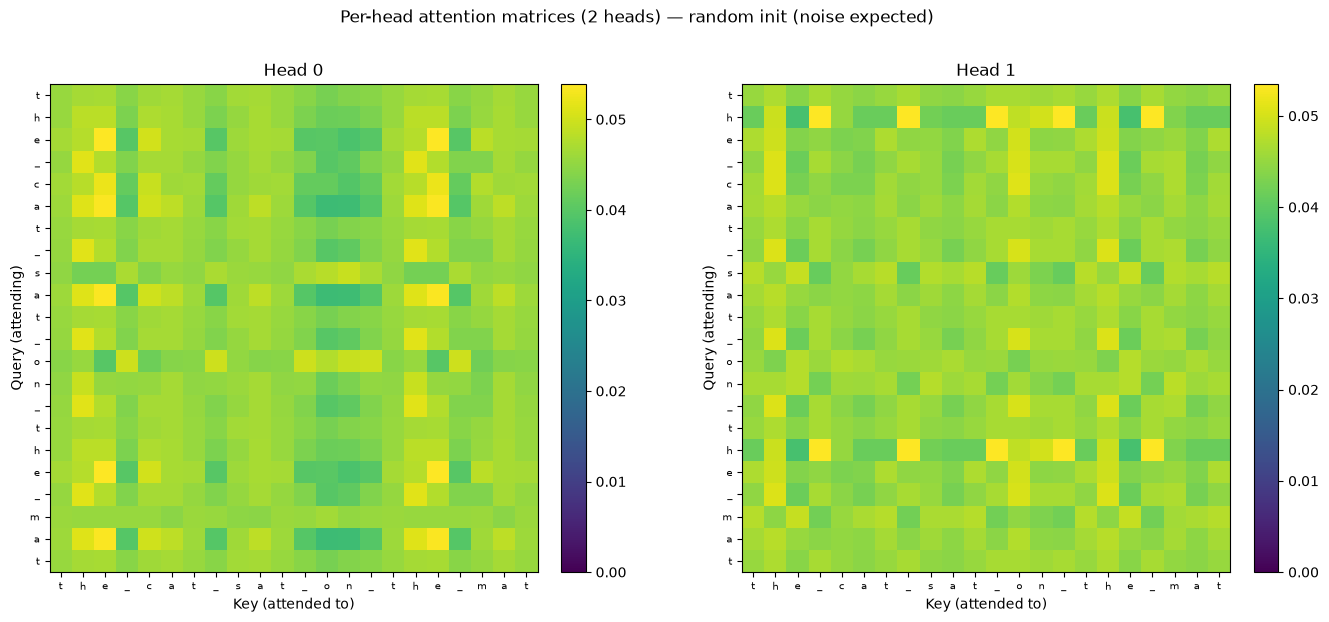

Each panel is one head's (T, T) attention. The panels differ because each head
has its own W_Q, W_K, W_V. That independence is what multi-head attention buys us.


In [9]:
labels = [('_' if ch == ' ' else ch) for ch in sentence]

fig, axes = plt.subplots(1, N_HEADS, figsize=(7 * N_HEADS, 6))
if N_HEADS == 1:
    axes = [axes]

for head, ax in enumerate(axes):
    im = ax.imshow(A_all[head], cmap="viridis", vmin=0, vmax=A_all[head].max())
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=7)
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_xlabel("Key (attended to)")
    ax.set_ylabel("Query (attending)")
    ax.set_title(f"Head {head}")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(f"Per-head attention matrices ({N_HEADS} heads) — random init (noise expected)", y=1.02)
plt.tight_layout()
plt.show()

print("Each panel is one head's (T, T) attention. The panels differ because each head")
print("has its own W_Q, W_K, W_V. That independence is what multi-head attention buys us.")

## Summary

| Step | Operation | Shape | What it adds |
|---|---|---|---|
| 5.2 | `Q,K,V = X @ W_*`, then split | `(T, d_model)` → `(h, T, d_k)` | Carves the feature space into `h` independent heads |
| 5.3 | `scaled_dot_product_attention` per head | `(h, T, d_k)` + `(h, T, T)` | `h` parallel attention patterns |
| 5.4 | concat + `@ W_O` | `(T, d_model)` | Recombines heads into one coherent representation |

**Key idea:** multi-head attention is *not* a new mechanism — it is the Section 4 primitive run `h` times in parallel over disjoint `d_k`-dimensional subspaces, then mixed by `W_O`. Same compute as one full-width head, but `h` independent relationships per layer.

`multi_head_attention(X, params)` is shape-preserving: `(T, d_model) → (T, d_model)`. That is what lets us stack it. The next ingredient is **positional encoding** (Section 6) — because attention as built so far is permutation-equivariant and has no notion of token order.
